In [ ]:
#unsupervised learning

In [7]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])   #This is the mean of the 3 features.
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(
    class1_sample,
    columns=['feature1', 'feature2', 'feature3']
)
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(
    class2_sample,
    columns=['feature1', 'feature2', 'feature3']
)
df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [8]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


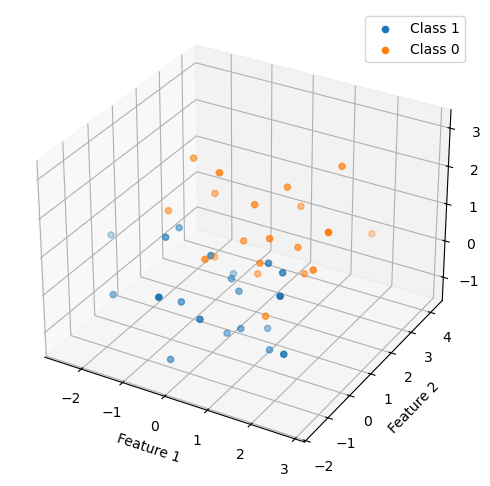

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

class1 = df[df['target'] == 1]
class2 = df[df['target'] == 0]

ax.scatter(
    class1['feature1'],
    class1['feature2'],
    class1['feature3'],
    label='Class 1'
)

ax.scatter(
    class2['feature1'],
    class2['feature2'],
    class2['feature3'],
    label='Class 0'
)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.legend()

plt.show()

In [11]:
#step 1 Apply standaed scaling

from sklearn.preprocessing import StandardScaler
sclaler = StandardScaler()
df.iloc[:,0:3] = sclaler.fit_transform(df.iloc[:,0:3])

In [12]:
#find covariance matrix of the features
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance matrix:\n%s' % covariance_matrix)

Covariance matrix:
[[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [13]:
#find eigen values and eigen vectors of the covariance matrix
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [15]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [16]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

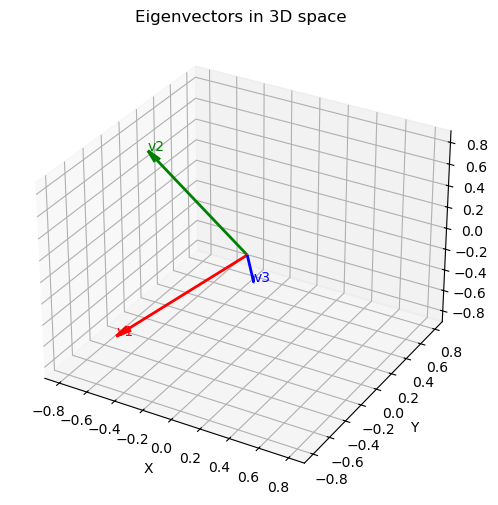

In [17]:


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b']
max_value = np.max(np.abs(eigen_vectors))
limit = max_value * 1.2 if max_value != 0 else 1

for index, color in enumerate(colors):
    vector = eigen_vectors[:, index]
    ax.quiver(0, 0, 0, vector[0], vector[1], vector[2], color=color, linewidth=2, arrow_length_ratio=0.1)
    ax.text(vector[0], vector[1], vector[2], f'v{index + 1}', color=color)

ax.set_xlim([-limit, limit])
ax.set_ylim([-limit, limit])
ax.set_zlim([-limit, limit])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Eigenvectors in 3D space')
plt.show()

In [18]:
principal_components = eigen_vectors[0:2]

In [ ]:
transformed_data = np.dot(df.iloc[:,0:3], principal_components.T)

In [20]:
new_df = pd.DataFrame(transformed_data, columns=['PC1', 'PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1
